# Análisis Exploratorio de datos
---
> Conjunto de datos obtenido del Servicio Sismológico Nacional, adscrito al Instituto de Geofísica de la Universidad Nacional Autónoma de México

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [53]:
df = pd.read_csv('SSNMX.csv', encoding = 'utf8', low_memory = False)

display(df.head())

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,06/12/2005,02:46:35,4.7,15.71,-95.99,15.0,"17 km al SURESTE de CRUCECITA, OAX",06/12/2005,08:46:35,revisado
1,06/12/2005,10:37:38,3.7,17.11,-100.25,40.0,"21 km al NOROESTE de COYUCA DE BENITEZ, GRO",06/12/2005,16:37:38,revisado
2,06/12/2005,16:22:35,3.8,15.74,-94.92,14.0,"57 km al SURESTE de SALINA CRUZ, OAX",06/12/2005,22:22:35,revisado
3,06/12/2005,17:37:48,3.6,16.36,-98.45,16.0,"36 km al SUR de OMETEPEC, GRO",06/12/2005,23:37:48,revisado
4,06/12/2005,20:18:56,3.8,16.21,-98.38,10.0,"38 km al SUROESTE de PINOTEPA NACIONAL, OAX",07/12/2005,02:18:56,revisado


In [54]:
def diagnose(df):
    """Función que evalúa estado general de un Dataset"""
    print(f'Registros totales: {df.size}')
    print(f'Registros duplicados: {df.duplicated().sum()}\n')

    diagnostico = pd.DataFrame({'columnas': df.columns, 
                            'tipo': df.dtypes, 
                            'faltantes': df.isnull().sum(),
                            'faltantes_%': (df.isnull().sum() / len(df)) * 100,
                            'unicos': df.nunique()})
    
    diagnostico = pd.concat([diagnostico, df.describe().T], axis=1) # Para unir todo en un solo reporte

    return(diagnostico)

display(diagnose(df))

Registros totales: 3486350
Registros duplicados: 0



,columnas,tipo,faltantes,faltantes_%,unicos,count,mean,std,min,25%,50%,75%,max
Fecha,Fecha,object,0,0.0,7476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hora,Hora,object,0,0.0,84649,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Magnitud,Magnitud,object,0,0.0,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitud,Latitud,float64,0,0.0,57790,348635.0,18.263955,4.240443,10.271,16.0397,16.7480,18.5000,38.0923
Longitud,Longitud,float64,0,0.0,59457,348635.0,-99.755937,6.105623,-120.595,-102.4810,-98.2237,-95.0077,-85.5467
Profundidad,Profundidad,float64,0,0.0,2249,348635.0,30.814877,36.139149,0.000,10.0000,16.0000,36.4000,338.0000
Referencia de localizacion,Referencia de localizacion,object,0,0.0,45201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fecha UTC,Fecha UTC,object,0,0.0,7471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hora UTC,Hora UTC,object,0,0.0,84685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estatus,Estatus,object,0,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observamos que la columna `Magnitud` está registrada como `object`, es decir, existen valores `string`o en otro formato. Dado que nos interesa tratar la magnitud como un valor numérico, forzamos la conversión.

In [55]:
df['Magnitud'] = pd.to_numeric(df['Magnitud'], errors='coerce')
errores = df[df['Magnitud'].isna()]
print('Registros no convertibles (Con magnitudes no calculables): {}'.format(len(errores)))

Registros no convertibles (Con magnitudes no calculables): 3


Repetimos y profundizamos el análisis usando únicamente las columnas totalmente numéricas.

In [56]:
df_num = df.select_dtypes(include=['float'])
display(diagnose(df_num))

Registros totales: 1394540
Registros duplicados: 807



,columnas,tipo,faltantes,faltantes_%,unicos,count,mean,std,min,25%,50%,75%,max
Magnitud,Magnitud,float64,3,0.00086,72,348632.0,3.466261,0.550316,0.300,3.3000,3.6000,3.8000,8.2000
Latitud,Latitud,float64,0,0.00000,57790,348635.0,18.263955,4.240443,10.271,16.0397,16.7480,18.5000,38.0923
Longitud,Longitud,float64,0,0.00000,59457,348635.0,-99.755937,6.105623,-120.595,-102.4810,-98.2237,-95.0077,-85.5467
Profundidad,Profundidad,float64,0,0.00000,2249,348635.0,30.814877,36.139149,0.000,10.0000,16.0000,36.4000,338.0000


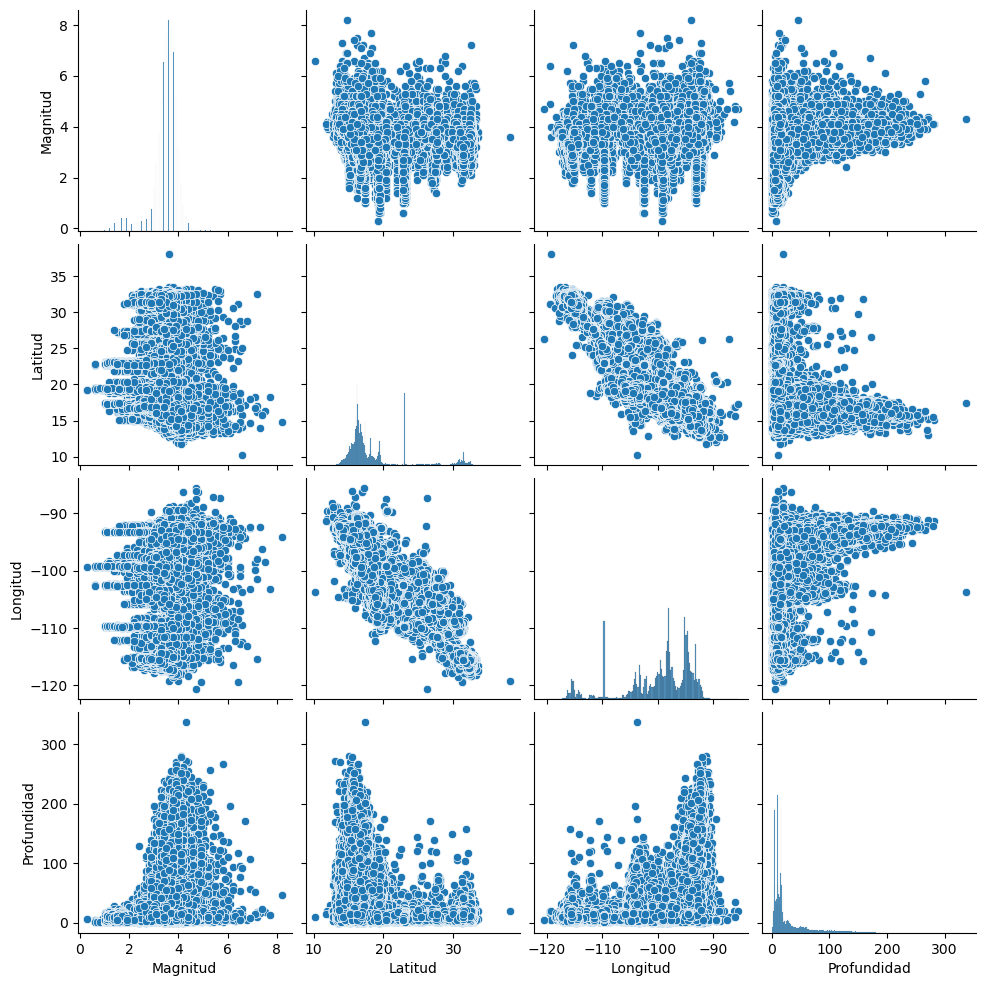

In [57]:
sns.pairplot(df_num)

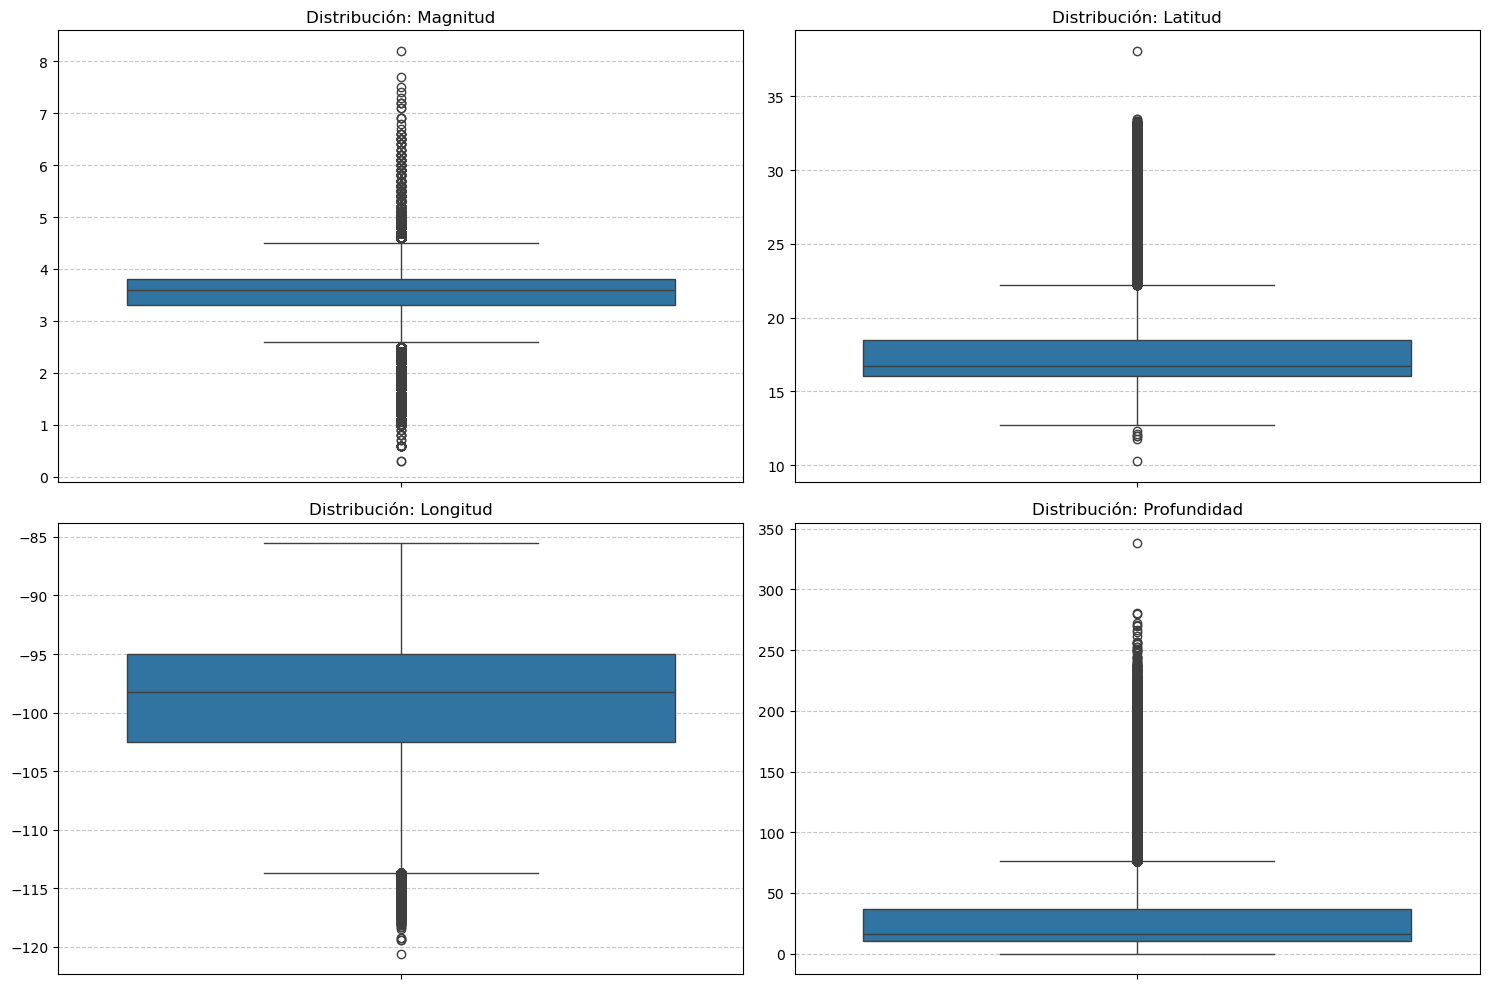

In [60]:
def graficar_outliers(df, columnas_por_fila=3):
    """Función que permite graficar Boxplots para todas las columnas de un dataset en una sola imagen"""
    columnas_numericas = df.select_dtypes(include=['number']).columns
    n_subs = len(columnas_numericas)
    n_filas = math.ceil(n_subs / columnas_por_fila) # Aseguramos que sea el número de columnas deseado
    
    fig, axes = plt.subplots(n_filas, columnas_por_fila, figsize=(15, n_filas * 5))
    axes = axes.flatten() # Para iterar en un solo ciclo

    for i, col in enumerate(columnas_numericas):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(f'Distribución: {col}', fontsize=12)
        axes[i].set_ylabel('')
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off') # Para que no se muestren ejes vacíos sobrantes

    plt.tight_layout()
    plt.show()

graficar_outliers(df, 2)

En este caso, los valores fuera de los rangos esperados no son necesariamente *outliers*: Los sismos de magnitudes y lugares poco frecuentes podrían aportar bastante al análisis. Por ende, en el preprocesamiento, sólo se eliminarán los registros con magnitudes no convertibles a valores numéricos y aquellos cuyas coordenadas estén fuera del territorio mexicano.